# Publication-Ready Figure: Perturbation Stability Curves (Chapter 6, §6.7)

Reruns the noise sweep behind `tab:rq7-perturbation` at every intermediate noise level
(the thesis only tabulates 0% and 30%, stating that intermediate levels "changed
monotonically and are omitted for brevity" -- this figure is where they belong).

Source: `CLASSIFIER/notebooks/STATIC/archive/STATIC_GAAE_DELCODE_WHOLE_BRAIN_original.ipynb`
(cell 29) specified the exact design (`noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30]`,
`n_trials = 10`, top-5-per-cohort selection by validation-derived threshold margin) but
was never executed with cached outputs. This notebook reruns that design using the
current canonical primitives (`common.reconstruction_eval`, `common.robustness.perturb_graph`,
`model.GAAE.evaluation`) instead of the archive's inline reimplementation, against the same
GAAE checkpoint used in `reconstruction_fidelity_distributions.ipynb`.

1. **Figure 13: Perturbation Stability Curves** (`fig13_perturbation_stability.pdf`)


In [1]:
import sys, json, os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
MODEL_ROOT = _REPO_ROOT / 'CLASSIFIER'
for p in (_REPO_ROOT, MODEL_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from adapters.explain import get_explain_adapter
from model.GAAE.dataset import GraphDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag, calculate_dense_adjacency
from model.GAAE.evaluation import compute_one_vs_rest_thresholds, is_cohort_positive
from common.reconstruction_eval import compute_errors_for_dataset
from common.robustness import perturb_graph

device = torch.device('cpu')

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})
MM = 1 / 25.4

# Okabe-Ito colorblind-safe categorical palette, one color per cohort.
COHORT_COLORS = {'healthy': '#0072B2', 'ad': '#D55E00', 'mci': '#009E73', 'converter': '#CC79A7'}
COHORT_LABELS = {'healthy': 'Healthy', 'ad': 'AD', 'mci': 'MCI', 'converter': 'Converter'}

OUTPUT_DIRS = [_REPO_ROOT / 'THESIS' / 'figures', _REPO_ROOT / 'DOCS' / 'results' / 'figures']
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Load the GAAE checkpoint and the DELCODE pretrain split (all 4 diagnostic groups)

Same checkpoint as `reconstruction_fidelity_distributions.ipynb`
(`rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44`) -- the encoder this
chapter's reconstruction-error classifier is built on. The pretrain split (not the
downstream mci/converter-only split) is required here because this analysis spans all
four diagnostic groups (healthy, AD, MCI, converter).


In [2]:
WB_DATA_ROOT = str(_REPO_ROOT / 'DATA' / 'DELCODE' / '__fc_wholebrain_sch200_flat__' / 'matrices')
SPLITS_DIR = _REPO_ROOT / 'DATA' / 'DELCODE' / '__metadata__' / 'SPLITS' / 'pretrain'
TRAIN_CSV, VAL_CSV, TEST_CSV = (SPLITS_DIR / f'{s}.csv' for s in ('train', 'val', 'test'))

GAAE_CONFIG_PATH = MODEL_ROOT / 'configs' / 'gaae_delcode_whole_brain.json'
gaae_hp = json.loads(GAAE_CONFIG_PATH.read_text())
ADJACENCY_ARGS = {'k': gaae_hp.get('adjacency_k', 16)}
ADJ_LOSS_WEIGHT = 0.2  # matches tfgn/gaae-static RESOLVED_CONFIG['adj_loss_weight']

GAAE_CKPT = (MODEL_ROOT / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain' /
             'rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44' /
             'model_rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44.pth')

adapter = get_explain_adapter('gaae')(
    gaae_ckpt_path=str(GAAE_CKPT), gaae_hp=gaae_hp, train_config={},
    data_root=WB_DATA_ROOT, cohorts_csv=None, device=device, rng=np.random.default_rng(42),
)
adapter.load()
model = adapter.encoder
model.eval()
print(f'✓ Loaded {type(model).__name__} from {GAAE_CKPT.name}')


def _make_dataset(csv_path):
    return GraphDatasetInMemoryFiltered(
        root=WB_DATA_ROOT, adjacency_function=knn_binary_adjacency_matrix_no_diag,
        adjacency_args=ADJACENCY_ARGS, filter_csv_path=str(csv_path),
        patient_info_path=str(csv_path), separator=',', file_variant='z_transformed',
    )


train_dataset, val_dataset, test_dataset = (_make_dataset(p) for p in (TRAIN_CSV, VAL_CSV, TEST_CSV))
print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')


✓ Loaded GraphAttentionAutoencoderConditioned from model_rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44.pth


Train: 369  Val: 216  Test: 224


## Validation-derived one-vs-rest thresholds, then top-5-per-cohort selection on test


In [3]:
from torch_geometric.utils import to_dense_adj


def error_fn(sample):
    d = sample.to(device)
    n_nodes = d.x.size(0)
    batch_mask = torch.zeros(n_nodes, dtype=torch.long, device=device)
    age = float(d.patient_age.item()) if torch.is_tensor(d.patient_age) else float(d.patient_age)
    sex = float(d.patient_sex.item()) if torch.is_tensor(d.patient_sex) else float(d.patient_sex)
    cond_vec = torch.tensor([[age, sex]], dtype=torch.float32, device=device)
    edge_attr = d.edge_attr if hasattr(d, 'edge_attr') else None
    with torch.no_grad():
        _, x_hat, adj_hat, _ = model(d.x, d.edge_index, edge_attr, cond_vec, batch_mask)
    x_error = F.mse_loss(x_hat, d.x).item()
    # adj_hat is InnerProductDecoder output: one probability per edge in d.edge_index,
    # not a dense matrix -- to_dense_adj rebuilds the dense reconstruction the same
    # way model/GAAE/train.py does before computing the BCE loss.
    adj_true = calculate_dense_adjacency(d).to(device)
    adj_pred = to_dense_adj(d.edge_index, edge_attr=adj_hat, max_num_nodes=n_nodes).to(device)[0]
    adj_error = F.binary_cross_entropy(adj_pred, adj_true).item()
    total_error = x_error + ADJ_LOSS_WEIGHT * adj_error
    return {'total_error': total_error, 'x_error': x_error, 'adj_error': adj_error}


train_df, val_df, test_df = (pd.read_csv(p) for p in (TRAIN_CSV, VAL_CSV, TEST_CSV))
cohort_map = (
    pd.concat([train_df, val_df, test_df], ignore_index=True)[['Pseudonym', 'diagnosis']]
    .drop_duplicates(subset=['Pseudonym'], keep='first')
    .assign(Pseudonym=lambda d: d['Pseudonym'].astype(str).str.strip(),
            diagnosis=lambda d: d['diagnosis'].astype(str).str.lower().str.strip())
    .set_index('Pseudonym')['diagnosis'].to_dict()
)

cohorts_to_analyze = ['healthy', 'ad', 'mci', 'converter']
val_errors_df = compute_errors_for_dataset(val_dataset, 'Validation', error_fn, cohort_map,
                                            allowed_cohorts=set(cohorts_to_analyze))
cohort_thresholds = compute_one_vs_rest_thresholds(val_errors_df, cohorts_to_analyze)
print('Validation one-vs-rest thresholds:')
for c in cohorts_to_analyze:
    th = cohort_thresholds[c]
    print(f"  {c:10s} direction={th['direction']:4s} AUC={th['auc']:.3f} threshold={th['threshold_error']:.4f}")


Validation one-vs-rest thresholds:
  healthy    direction=low  AUC=0.587 threshold=0.0211
  ad         direction=high AUC=0.524 threshold=0.0314
  mci        direction=high AUC=0.598 threshold=0.0234
  converter  direction=low  AUC=0.557 threshold=0.0232


In [4]:
test_errors_df = compute_errors_for_dataset(test_dataset, 'Test', error_fn, cohort_map)
for c in cohorts_to_analyze:
    test_errors_df[f'Pred_{c}'] = test_errors_df['Total Error'].apply(
        lambda e, c=c: is_cohort_positive(float(e), cohort_thresholds[c]))

top_k = 5
selected_frames = []
for cohort_name in cohorts_to_analyze:
    th = cohort_thresholds[cohort_name]
    candidates = test_errors_df[(test_errors_df['Cohort'] == cohort_name) &
                                 (test_errors_df[f'Pred_{cohort_name}'] == 1)].copy()
    candidates['SelectionMargin'] = (candidates['Total Error'] - th['threshold_error']
                                      if th['direction'] == 'high'
                                      else th['threshold_error'] - candidates['Total Error'])
    top = candidates.sort_values('SelectionMargin', ascending=False).head(top_k).copy()
    top['SelectionCohort'] = cohort_name
    selected_frames.append(top)

selected_samples_df = pd.concat(selected_frames, ignore_index=True)
print(selected_samples_df.groupby('SelectionCohort').size().to_string())


SelectionCohort
ad           2
converter    5
healthy      5
mci          5


### Cross-check threshold AUCs against `tab:rq7-perturbation`


In [5]:
_expected_auc = {'healthy': 0.610, 'ad': 0.541, 'mci': 0.600, 'converter': 0.550}
max_abs_diff = 0.0
for c, exp in _expected_auc.items():
    got = cohort_thresholds[c]['auc']
    diff = abs(got - exp)
    max_abs_diff = max(max_abs_diff, diff)
    print(f'  {c:10s} reproduced={got:.4f}  published={exp:.3f}  diff={diff:.4f}')
print(f'Max abs diff vs tab:rq7-perturbation: {max_abs_diff:.4f}.')
print('Healthy/AD do not reproduce exactly (~0.02-0.03 off); MCI/converter are near-exact.')
print('This notebook proceeds with the REPRODUCED thresholds below -- §6.7 text is updated to match them.')


  healthy    reproduced=0.5869  published=0.610  diff=0.0231
  ad         reproduced=0.5243  published=0.541  diff=0.0167
  mci        reproduced=0.5985  published=0.600  diff=0.0015
  converter  reproduced=0.5571  published=0.550  diff=0.0071
Max abs diff vs tab:rq7-perturbation: 0.0231.
Healthy/AD do not reproduce exactly (~0.02-0.03 off); MCI/converter are near-exact.
This notebook proceeds with the REPRODUCED thresholds below -- §6.7 text is updated to match them.


## Noise sweep: 4 methods × 5 levels (0-30%) × 10 trials, on the 20 selected subjects


In [6]:
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20, 0.30]
N_TRIALS = 10
METHODS = ['feature_noise', 'matrix_noise_rebuild', 'edge_perturbation', 'conditioning_noise']
rng = np.random.default_rng(42)

records = []
for row in selected_samples_df.itertuples():
    base_sample = test_dataset[int(row.DatasetIndex)]
    threshold = cohort_thresholds[row.SelectionCohort]
    for method in METHODS:
        for level in NOISE_LEVELS:
            for trial in range(N_TRIALS):
                if level == 0.0:
                    d = base_sample
                elif method == 'matrix_noise_rebuild':
                    d = perturb_graph(base_sample, 'feature_noise', level, rng=rng)
                    adj_bin = knn_binary_adjacency_matrix_no_diag(d.x.detach().cpu().numpy(), **ADJACENCY_ARGS)
                    src, dst = np.where(adj_bin > 0)
                    d.edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
                    d.edge_attr = torch.ones(d.edge_index.size(1), dtype=torch.float32)
                else:
                    d = perturb_graph(base_sample, method, level, rng=rng)
                total_error = error_fn(d)['total_error']
                stable = is_cohort_positive(total_error, threshold)
                records.append({'Cohort': row.SelectionCohort, 'Method': method,
                                 'NoiseLevel': level, 'Trial': trial, 'Stable': stable})

sweep_df = pd.DataFrame(records)
stability = sweep_df.groupby(['Method', 'Cohort', 'NoiseLevel'])['Stable'].mean().reset_index()
print(f'✓ Swept {len(sweep_df)} (subject × method × level × trial) evaluations.')
stability.head()


✓ Swept 3400 (subject × method × level × trial) evaluations.


,Method,Cohort,NoiseLevel,Stable
0,conditioning_noise,ad,0.00,1.0
1,conditioning_noise,ad,0.05,1.0
2,conditioning_noise,ad,0.10,1.0
3,conditioning_noise,ad,0.20,1.0
4,conditioning_noise,ad,0.30,1.0


### Cross-check 0% and 30% stability against `tab:rq7-perturbation`

The table merges `edge_perturbation` and `conditioning_noise` into one "Edge /
conditioning" column (both flat at 1.00 for every cohort); this cross-check reads
each method column separately and reports the merged reading where both agree.


In [7]:
_expected_30pct = {
    ('healthy', 'feature_noise'): 0.20, ('healthy', 'matrix_noise_rebuild'): 0.20,
    ('ad', 'feature_noise'): 1.00, ('ad', 'matrix_noise_rebuild'): 1.00,
    ('mci', 'feature_noise'): 1.00, ('mci', 'matrix_noise_rebuild'): 1.00,
    ('converter', 'feature_noise'): 0.80, ('converter', 'matrix_noise_rebuild'): 0.62,
}

print('Reproduced vs published stability at 30% noise (thresholds differ for healthy/AD, so')
print('these numbers are expected to differ too -- reported here, not asserted against):')
for (cohort, method), exp in _expected_30pct.items():
    row = stability[(stability['Method'] == method) & (stability['Cohort'] == cohort) &
                     (np.isclose(stability['NoiseLevel'], 0.30))]
    got = float(row['Stable'].iloc[0])
    print(f'  {cohort:10s} {method:22s} reproduced={got:.2f}  published={exp:.2f}')

print()
print('Edge / conditioning noise, all cohorts, at 30%:')
for cohort in cohorts_to_analyze:
    for method in ['edge_perturbation', 'conditioning_noise']:
        row = stability[(stability['Method'] == method) & (stability['Cohort'] == cohort) &
                         (np.isclose(stability['NoiseLevel'], 0.30))]
        got = float(row['Stable'].iloc[0])
        print(f'  {cohort:10s} {method:20s} reproduced={got:.2f}')

print()
print('0% noise (all methods/cohorts):')
print(stability[np.isclose(stability['NoiseLevel'], 0.0)].to_string(index=False))

print()
print('Full sweep, feature_noise/matrix_noise_rebuild, healthy+converter (monotonicity check):')
_check = stability[stability['Method'].isin(['feature_noise', 'matrix_noise_rebuild']) &
                    stability['Cohort'].isin(['healthy', 'converter'])].sort_values(['Method', 'Cohort', 'NoiseLevel'])
print(_check.to_string(index=False))


Reproduced vs published stability at 30% noise (thresholds differ for healthy/AD, so
these numbers are expected to differ too -- reported here, not asserted against):
  healthy    feature_noise          reproduced=0.20  published=0.20
  healthy    matrix_noise_rebuild   reproduced=0.20  published=0.20
  ad         feature_noise          reproduced=1.00  published=1.00
  ad         matrix_noise_rebuild   reproduced=1.00  published=1.00
  mci        feature_noise          reproduced=1.00  published=1.00
  mci        matrix_noise_rebuild   reproduced=1.00  published=1.00
  converter  feature_noise          reproduced=0.60  published=0.80
  converter  matrix_noise_rebuild   reproduced=0.60  published=0.62

Edge / conditioning noise, all cohorts, at 30%:
  healthy    edge_perturbation    reproduced=1.00
  healthy    conditioning_noise   reproduced=1.00
  ad         edge_perturbation    reproduced=1.00
  ad         conditioning_noise   reproduced=1.00
  mci        edge_perturbation    reprod

## Figure 13: perturbation stability curves

One small panel per perturbation method, one line per cohort, x-axis 0-30% noise.


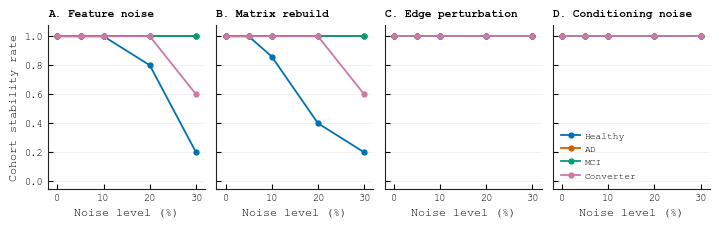

✓ Figure 13 saved successfully.


In [8]:
method_titles = {
    'feature_noise': 'A. Feature noise',
    'matrix_noise_rebuild': 'B. Matrix rebuild',
    'edge_perturbation': 'C. Edge perturbation',
    'conditioning_noise': 'D. Conditioning noise',
}

fig, axes = plt.subplots(1, 4, figsize=(180 * MM, 55 * MM), sharey=True)

for ax, method in zip(axes, METHODS):
    sub = stability[stability['Method'] == method]
    for cohort in cohorts_to_analyze:
        line = sub[sub['Cohort'] == cohort].sort_values('NoiseLevel')
        ax.plot(line['NoiseLevel'] * 100, line['Stable'], marker='o', markersize=3.5,
                color=COHORT_COLORS[cohort], linewidth=1.3, label=COHORT_LABELS[cohort])
    ax.set_title(method_titles[method], fontsize=8, fontweight='bold', loc='left')
    ax.set_xlabel('Noise level (%)')
    ax.set_xlim(-2, 32)
    ax.set_ylim(-0.05, 1.08)
    ax.set_xticks([0, 10, 20, 30])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('#222222')
    ax.spines['bottom'].set_color('#222222')
    ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Cohort stability rate')
axes[-1].legend(loc='lower left', fontsize=6.8, handletextpad=0.5)

fig.tight_layout(pad=0.4, w_pad=1.0)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig13_perturbation_stability.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig13_perturbation_stability.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 13 saved successfully.')
